<a href="https://colab.research.google.com/github/A-Vineela/IIIT-H-Projects-and-Labs/blob/main/Module-4/Lab/Lab-1/Sonar_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
data=pd.read_csv("sonar.csv",header=None)
print("Dataset Shape:",data.shape)

Dataset Shape: (208, 61)


In [5]:
X=data.iloc[:,:-1].values
y=data.iloc[:,-1].values
# Convert labels:
# R -> -1
# M -> +1
y=np.where(y=='R',-1,1)

In [6]:
print("Feature Matrix Shape:",X.shape)
print("Label Vector Shape:",y.shape)

Feature Matrix Shape: (208, 60)
Label Vector Shape: (208,)


In [7]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [8]:
bias=-1*np.ones((X.shape[0],1))
X=np.hstack((X, bias))
print("Shape after bias:",X.shape)

Shape after bias: (208, 61)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [10]:
def perceptron_algo_plot(X, Y):
    #Train perceptron and plot total loss per epoch.
    w=np.zeros(X.shape[1])
    eta=0.01
    epochs=50
    errors=[]
    for epoch in range(epochs):
        total_error=0
        for i in range(len(X)):
            activation=np.dot(X[i],w)
            if activation*Y[i]<=0:
                total_error+=activation*Y[i]
                w=w+eta*X[i]*Y[i]
        errors.append(-total_error)
    plt.figure(figsize=(8,5))
    plt.plot(errors,marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Total Loss")
    plt.title("Perceptron Error Plot : Sonar Dataset")
    plt.grid(True)
    plt.show()
    return w

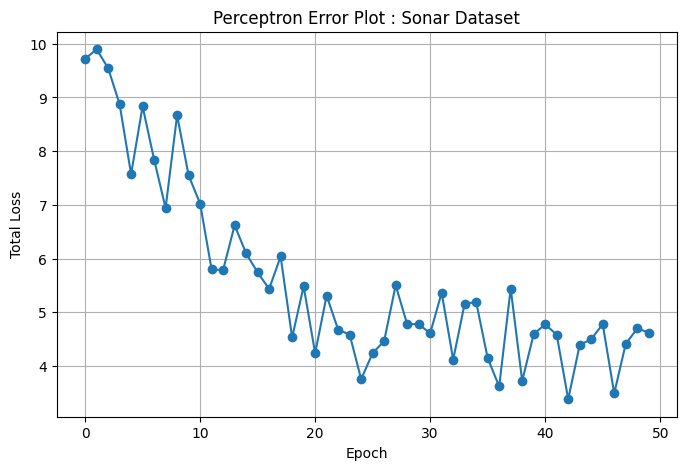


Learned Weight Vector:
[ 0.12442542  0.14373684 -0.29560373  0.33557903 -0.18384457  0.18719764
 -0.25255788 -0.1877971   0.3250703   0.02931966  0.14602025  0.20393346
 -0.14219487 -0.04592265  0.0104023  -0.18890445 -0.18846503  0.16271021
 -0.00111842  0.15334874 -0.14936224  0.36786541  0.06422562  0.00187099
  0.17906513 -0.18716394  0.03042135 -0.04272219  0.09601538  0.27877607
 -0.6049215   0.27619648  0.11632524 -0.08803913  0.07277367 -0.31453981
 -0.27353325  0.13491362  0.1444347  -0.32269303 -0.02159533  0.06506615
  0.15420802  0.07270805  0.20690939  0.00445307  0.15488821  0.36523904
  0.18496957 -0.29928177  0.04006813  0.13440809  0.1583819  -0.03714538
  0.05042569  0.03434603  0.0515924   0.07966104 -0.01080278  0.12390002
 -0.16      ]


In [11]:
w=perceptron_algo_plot(X_train, y_train)
print("\nLearned Weight Vector:")
print(w)

In [12]:
def predict(X,w):
    predictions = []
    for sample in X:
        y_hat=np.sign(np.dot(sample,w))
        if y_hat==0:
            y_hat=1
        predictions.append(y_hat)
    return np.array(predictions)

In [13]:
y_pred=predict(X_test,w)
accuracy=np.mean(y_pred==y_test)
print("\nTest Accuracy:")
print(f"{accuracy*100:.2f}%")


Test Accuracy:
76.19%


In [14]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[17  3]
 [ 7 15]]


In [15]:
train_pred=predict(X_train,w)
train_accuracy=np.mean(train_pred==y_train)
print(f"\nTraining Accuracy: {train_accuracy*100:.2f}%")


Training Accuracy: 92.77%
